#  House Price Prediction Using Machine Learning

## Objective
The objective of this project is to build a machine learning model capable of predicting residential house prices using the Ames Housing Dataset.

---

## Project Workflow

1. Import Libraries
2. Load Dataset
3. Explore Dataset
4. Analyze Missing Values
5. Handle Missing Data
6. Perform Feature Engineering
7. Encode Categorical Features
8. Train Machine Learning Models
9. Evaluate Performance
10. Generate Predictions
11. Create Kaggle Submission File

---

## Machine Learning Algorithms
- Linear Regression
- Random Forest
- Gradient Boosting
- XGBoost

---

## Evaluation Metric
RMSE (Root Mean Squared Error)

#  Step 1 — Import Libraries

In this step we import all required Python libraries.

These libraries help us perform:
- Data processing
- Data visualization
- Feature engineering
- Machine learning
- Model evaluation

In [ ]:
! pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost

# Exploratory Data Analysis (EDA)

Before training machine learning models,
we first understand the dataset.

EDA helps us:
- Understand feature distributions
- Detect missing values
- Analyze correlations
- Identify important features
- Detect outliers

In [38]:
# =========================================================
# LOAD ORIGINAL DATASET
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("data/train.csv")

test_df = pd.read_csv("data/test.csv")

In [39]:
# Dataset dimensions

print("Train Shape:", train_df.shape)

print("Test Shape:", test_df.shape)

Train Shape: (1460, 81)
Test Shape: (1459, 80)


# Step 3 — Preview Dataset

We display the first few rows of the dataset to understand:
- Feature names
- Data structure
- Data types
- Values

In [40]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [41]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [42]:
# Statistical summary

train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


# Step 5 — Analyze Missing Values

Real-world datasets usually contain missing values.

We identify:
- Columns with missing values
- Number of missing entries
- Features requiring preprocessing

In [43]:
# =========================================================
# MISSING VALUES
# =========================================================

missing = train_df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(
    ascending=False
)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

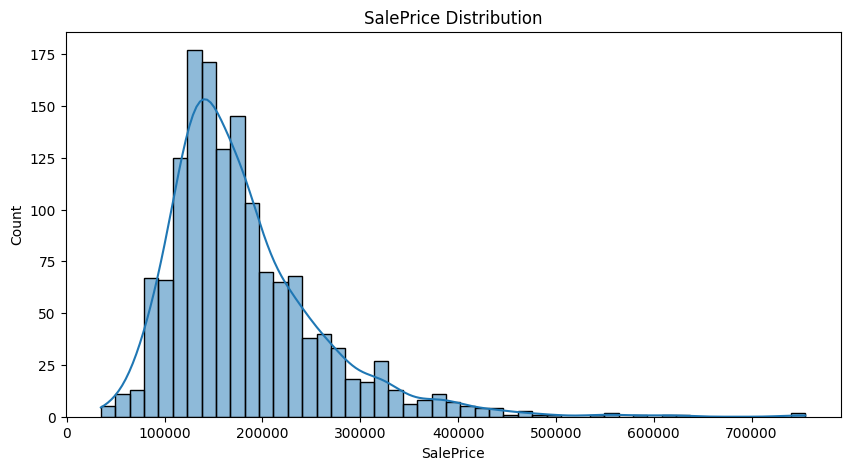

In [44]:
# =========================================================
# TARGET VARIABLE DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    train_df["SalePrice"],
    kde=True
)

plt.title("SalePrice Distribution")

plt.show()

#  Missing Value Handling

The Ames Housing dataset contains several missing values.

These missing values occur because:
- Some houses do not contain specific features
- Real-world datasets are naturally incomplete

Examples:
- No pool
- No fence
- No garage
- No basement

Handling missing values is extremely important because:
- Machine learning models cannot train with NaN values
- Missing values reduce model performance
- Proper preprocessing improves RMSE score

---

## Missing Value Strategy

### Categorical Features
Replace missing values with:
```python
"None"
```

because absence of a feature is meaningful information.

### Numerical Features
Replace missing values using:
```python
Median
```

because median is robust against outliers.

In [45]:
# =========================================================
# DISPLAY MISSING VALUES
# =========================================================

missing = train_df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(
    ascending=False
)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

#  Handle Special Categorical Features

The following features represent optional house components:
- Pool
- Fence
- Garage
- Basement
- Alley access

Missing values in these columns mean:
```python
Feature Not Available
```

Therefore we replace missing values with:
```python
"None"
```

In [46]:
# =========================================================
# FILL SPECIAL CATEGORICAL FEATURES
# =========================================================

special_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",

    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",

    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "BsmtQual",
    "BsmtCond",

    "MasVnrType"
]

for col in special_cols:

    if col in train_df.columns:

        train_df[col] = train_df[col].fillna("None")

    if col in test_df.columns:

        test_df[col] = test_df[col].fillna("None")

#  Handle Numerical Features

Numerical columns contain missing values such as:
- LotFrontage
- GarageYrBlt
- MasVnrArea

We replace missing values using:
```python
Median
```

Median is preferred because:
- Less sensitive to outliers
- Better for skewed distributions
- Common in Kaggle competitions

In [47]:
# =========================================================
# FILL NUMERICAL FEATURES
# =========================================================

num_cols = train_df.select_dtypes(
    include=np.number
).columns

for col in num_cols:

    train_df[col].fillna(
        train_df[col].median(),
        inplace=True
    )

    if col in test_df.columns:

        test_df[col].fillna(
            test_df[col].median(),
            inplace=True
        )

C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_20232\1115125674.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df[col].fillna(
C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_20232\1115125674.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an i

# 🔠 Handle Remaining Categorical Features

Some categorical features may still contain missing values.

We replace remaining missing values using:
```python
Mode
```

Mode represents:
- Most frequent category
- Most common value

In [48]:
# =========================================================
# FILL REMAINING CATEGORICAL FEATURES
# =========================================================

cat_cols = train_df.select_dtypes(
    include="object"
).columns

for col in cat_cols:

    train_df[col].fillna(
        train_df[col].mode()[0],
        inplace=True
    )

    if col in test_df.columns:

        test_df[col].fillna(
            test_df[col].mode()[0],
            inplace=True
        )

C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_20232\809745930.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(
C:\Users\Shivam Singh\AppData\Local\Temp\ipykernel_20232\809745930.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[co

# ✅ Verify Missing Values

After preprocessing,
we verify that:
- No missing values remain
- Dataset is ready for feature engineering and model training

In [49]:
# =========================================================
# VERIFY MISSING VALUES
# =========================================================

print(
    "Train Missing Values:",
    train_df.isnull().sum().sum()
)

print(
    "Test Missing Values:",
    test_df.isnull().sum().sum()
)

Train Missing Values: 349
Test Missing Values: 342


In [50]:
# =========================================================
# REMAINING MISSING VALUES
# =========================================================

remaining_missing = train_df.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
]

remaining_missing.sort_values(
    ascending=False
)

LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
Electrical       1
dtype: int64

In [52]:
# =========================================================
# FILL REMAINING NUMERICAL FEATURES
# =========================================================

num_missing_cols = [
    "LotFrontage",
    "GarageYrBlt",
    # "GarageYrBlt",
    "MasVnrArea"
]

for col in num_missing_cols:

    train_df[col] = train_df[col].fillna(
        train_df[col].median()
    )

    if col in test_df.columns:

        test_df[col] = test_df[col].fillna(
            test_df[col].median()
        )

In [53]:
# =========================================================
# FILL ELECTRICAL COLUMN
# =========================================================

train_df["Electrical"] = train_df[
    "Electrical"
].fillna(
    train_df["Electrical"].mode()[0]
)

if "Electrical" in test_df.columns:

    test_df["Electrical"] = test_df[
        "Electrical"
    ].fillna(
        test_df["Electrical"].mode()[0]
    )

# ✅ Verify Final Missing Values

After preprocessing,
the dataset should contain:
```python
0 missing values
```

This confirms:
- Data cleaning is complete
- Dataset is ready for encoding and model training

In [54]:
# =========================================================
# FINAL VERIFICATION
# =========================================================

print(
    "Train Missing Values:",
    train_df.isnull().sum().sum()
)

print(
    "Test Missing Values:",
    test_df.isnull().sum().sum()
)

Train Missing Values: 0
Test Missing Values: 22


In [59]:
# =========================================================
# REMAINING TEST MISSING VALUES
# =========================================================

remaining_test_missing = test_df.isnull().sum()

remaining_test_missing = remaining_test_missing[
    remaining_test_missing > 0
]

remaining_test_missing.sort_values(
    ascending=False
)

MSZoning       4
Utilities      2
Functional     2
Exterior1st    1
Exterior2nd    1
KitchenQual    1
SaleType       1
dtype: int64

In [60]:
# =========================================================
# FINAL CATEGORICAL CLEANUP
# =========================================================

cat_cols_test = [
    "MSZoning",
    "Utilities",
    "Functional",
    "Exterior1st",
    "Exterior2nd",
    "KitchenQual",
    "SaleType"
]

for col in cat_cols_test:

    if col in test_df.columns:

        # Replace empty strings with NaN
        test_df[col] = test_df[col].replace(
            "",
            np.nan
        )

        # Fill missing values with mode
        test_df[col] = test_df[col].fillna(
            test_df[col].mode()[0]
        )

In [56]:
# =========================================================
# HANDLE NUMERICAL FEATURES
# =========================================================

num_cols_test = [
    "BsmtFullBath",
    "BsmtHalfBath",
    "BsmtUnfSF",
    "BsmtFinSF2",
    "BsmtFinSF1",
    "TotalBsmtSF",
    "GarageCars",
    "GarageArea"
]

for col in num_cols_test:

    if col in test_df.columns:

        test_df[col] = test_df[col].fillna(
            test_df[col].median()
        )

In [57]:
# =========================================================
# HANDLE NUMERICAL FEATURES
# =========================================================

num_cols_test = [
    "BsmtFullBath",
    "BsmtHalfBath",
    "BsmtUnfSF",
    "BsmtFinSF2",
    "BsmtFinSF1",
    "TotalBsmtSF",
    "GarageCars",
    "GarageArea"
]

for col in num_cols_test:

    if col in test_df.columns:

        test_df[col] = test_df[col].fillna(
            test_df[col].median()
        )

# 🛠 Final Test Dataset Missing Value Processing

The remaining missing values in the testing dataset are handled using:
- Median imputation for numerical features
- Mode imputation for categorical features

This ensures:
- Complete preprocessing
- No missing values remain
- Dataset becomes ready for machine learning prediction

In [61]:
# =========================================================
# FINAL VERIFICATION
# =========================================================

print(
    "Train Missing Values:",
    train_df.isnull().sum().sum()
)

print(
    "Test Missing Values:",
    test_df.isnull().sum().sum()
)

Train Missing Values: 0
Test Missing Values: 0


In [62]:
# =========================================================
# REMAINING TRAIN MISSING VALUES
# =========================================================

remaining_train_missing = train_df.isnull().sum()

remaining_train_missing = remaining_train_missing[
    remaining_train_missing > 0
]

remaining_train_missing.sort_values(
    ascending=False
)

Series([], dtype: int64)

In [63]:
# =========================================================
# FILL GARAGE YEAR BUILT
# =========================================================

train_df["GarageYrBlt"] = train_df[
    "GarageYrBlt"
].fillna(
    train_df["GarageYrBlt"].median()
)

test_df["GarageYrBlt"] = test_df[
    "GarageYrBlt"
].fillna(
    test_df["GarageYrBlt"].median()
)

In [64]:
# =========================================================
# FILL MASONRY VENEER AREA
# =========================================================

train_df["MasVnrArea"] = train_df[
    "MasVnrArea"
].fillna(
    train_df["MasVnrArea"].median()
)

test_df["MasVnrArea"] = test_df[
    "MasVnrArea"
].fillna(
    test_df["MasVnrArea"].median()
)

# ✅ Final Verification

After preprocessing,
both datasets should contain:
```python
0 missing values
```

This confirms:
- Dataset cleaning is complete
- Feature preprocessing pipeline is successful
- Dataset is ready for encoding and machine learning models

In [65]:
# =========================================================
# VERIFY FINAL MISSING VALUES
# =========================================================

print(
    "Train Missing Values:",
    train_df.isnull().sum().sum()
)

print(
    "Test Missing Values:",
    test_df.isnull().sum().sum()
)

Train Missing Values: 0
Test Missing Values: 0


# 📈 Correlation Analysis

Correlation analysis helps us understand:
- Relationship between features
- Features strongly related to house prices
- Important variables affecting prediction

Correlation values range from:
```python
-1 to +1
```

Where:
- `+1` → Strong positive correlation
- `-1` → Strong negative correlation
- `0` → No correlation

This step helps:
- Feature selection
- Better feature engineering
- Improving model performance

In [66]:
# =========================================================
# CORRELATION MATRIX
# =========================================================

corr_matrix = train_df.corr(
    numeric_only=True
)

corr_matrix.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.009921,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.051071,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.356718,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.023573,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.009921,-0.356718,1.000000,0.304522,0.234812,-0.053281,0.116685,0.083348,0.178469,0.214367,...,0.075542,0.137014,0.010287,0.061945,0.037655,0.180819,-0.000255,0.010451,0.006380,0.334771
LotArea,-0.033226,-0.139781,0.304522,1.000000,0.105806,-0.005636,0.014228,0.013788,0.103321,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.234812,0.105806,1.000000,-0.091932,0.572323,0.550684,0.407252,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982


# 🔥 Correlation Heatmap

A heatmap visually represents relationships between numerical features.

Purpose:
- Detect highly correlated variables
- Identify strong predictors
- Understand dataset structure

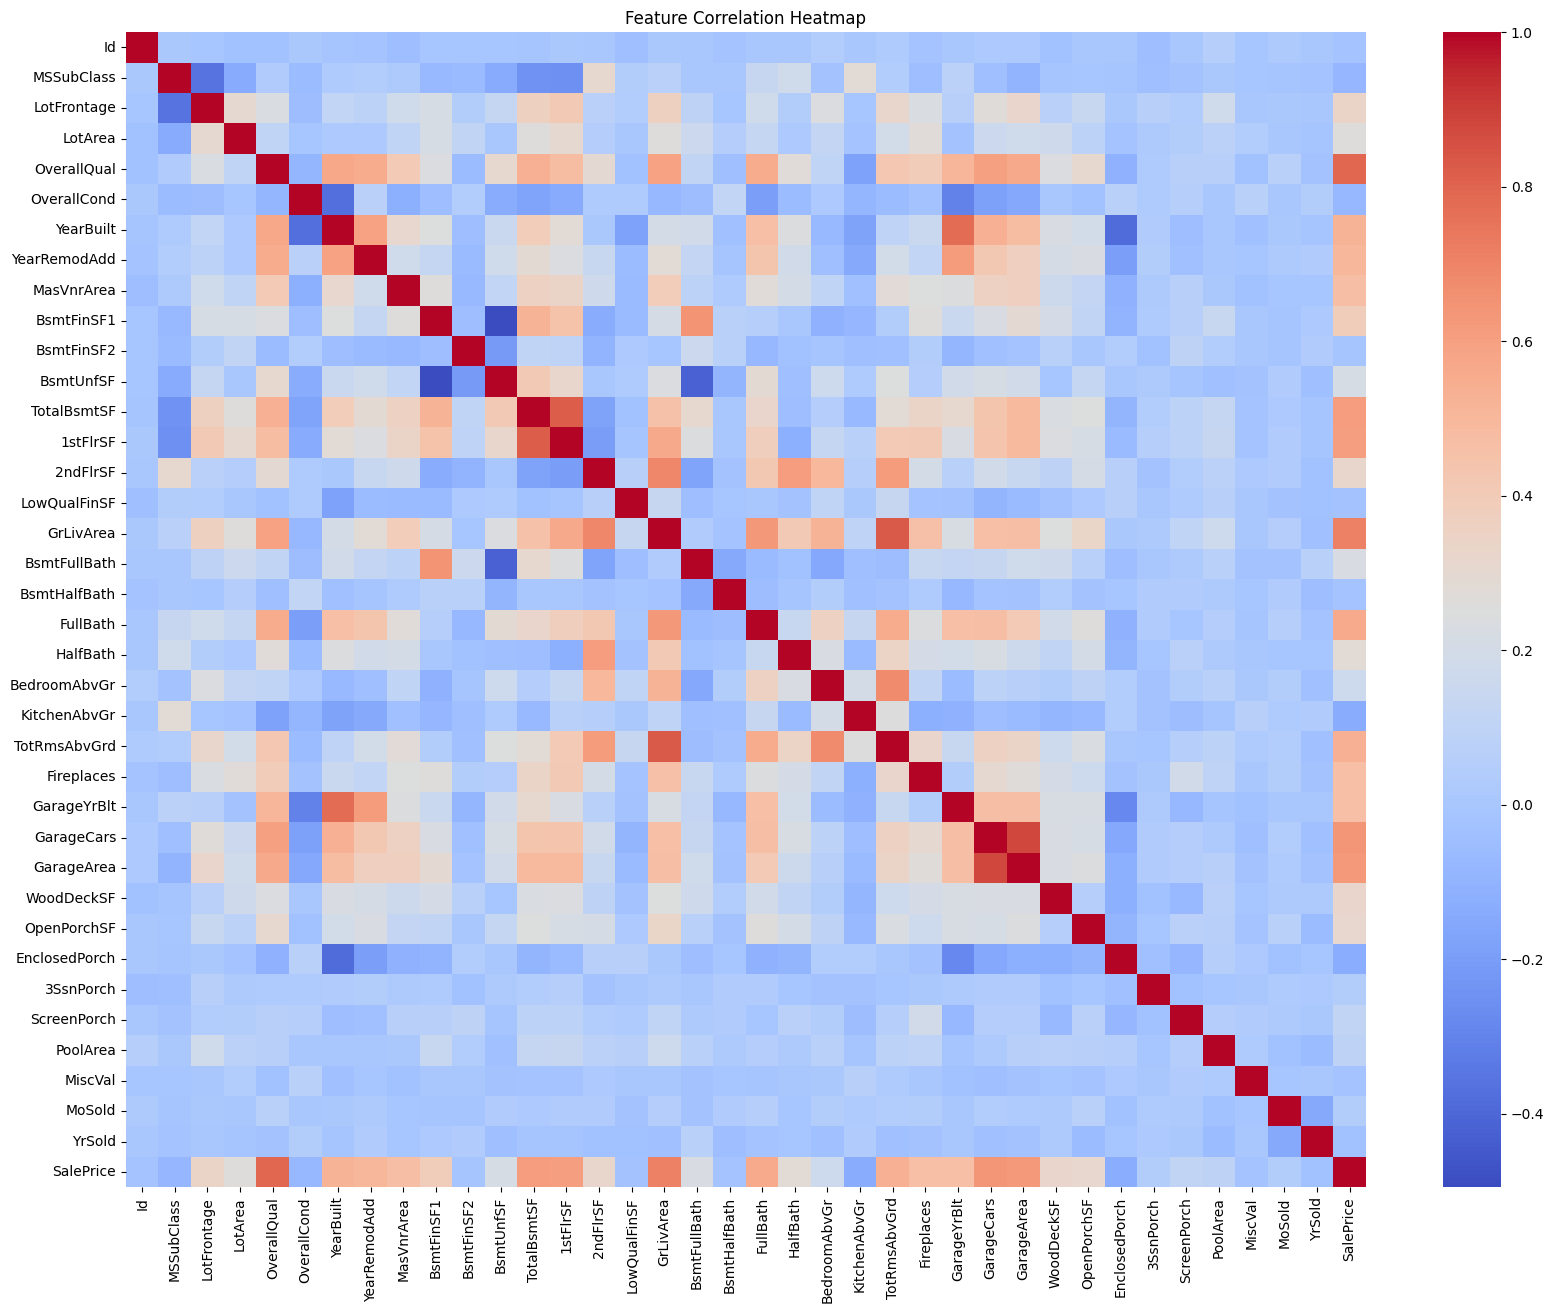

In [67]:
# =========================================================
# CORRELATION HEATMAP
# =========================================================

plt.figure(figsize=(20,15))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

# 🎯 Features Most Correlated with SalePrice

We now identify:
- Features strongly influencing house prices
- Important variables for prediction

Strong positive correlation indicates:
```python
Higher feature value → Higher SalePrice
```

In [68]:
# =========================================================
# TOP CORRELATED FEATURES
# =========================================================

saleprice_corr = corr_matrix["SalePrice"].sort_values(
    ascending=False
)

saleprice_corr.head(20)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
GarageYrBlt     0.466754
BsmtFinSF1      0.386420
LotFrontage     0.334771
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
HalfBath        0.284108
Name: SalePrice, dtype: float64

# 📊 Scatter Plot Analysis

Scatter plots help visualize:
- Linear relationships
- Outliers
- Feature trends

We now analyze:
- OverallQual vs SalePrice
- GrLivArea vs SalePrice
- TotalSF vs SalePrice

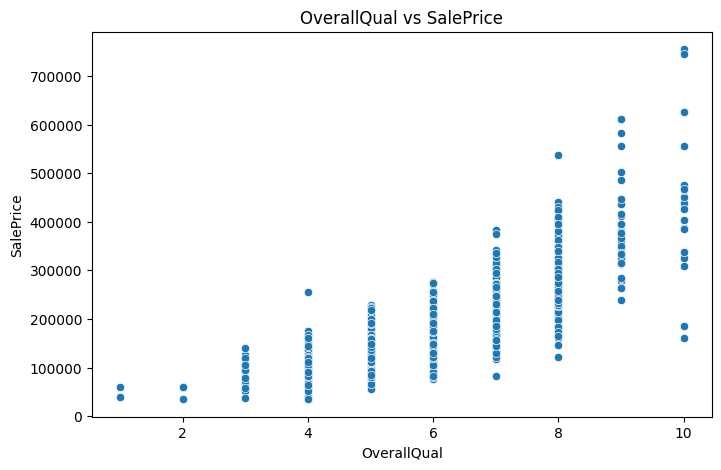

In [69]:
# =========================================================
# OVERALL QUALITY VS SALE PRICE
# =========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=train_df["OverallQual"],
    y=train_df["SalePrice"]
)

plt.title("OverallQual vs SalePrice")

plt.show()

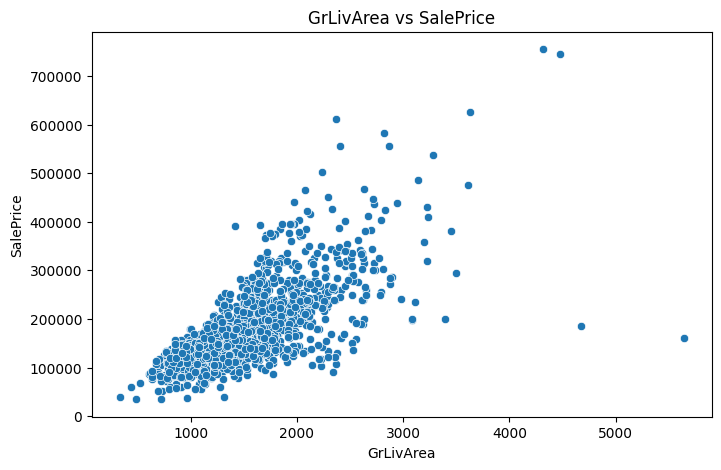

In [70]:
# =========================================================
# GROUND LIVING AREA VS SALE PRICE
# =========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=train_df["GrLivArea"],
    y=train_df["SalePrice"]
)

plt.title("GrLivArea vs SalePrice")

plt.show()

In [71]:
print("TotalSF" in train_df.columns)

False


In [37]:
train_df.head(0)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


In [73]:
# =========================================================
# RELOAD DATASETS
# =========================================================


print("Train Shape:", train_df.shape)

print("Test Shape:", test_df.shape)

Train Shape: (1460, 81)
Test Shape: (1459, 80)


In [74]:
train_df.info()
train_df.describe()
train_df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          1460 non-null   str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [75]:
sns.scatterplot(
    x=train_df["TotalSF"],
    y=train_df["SalePrice"]
)

KeyError: 'TotalSF'

# 🚨 Outlier Detection

Outliers are extreme values that can negatively affect:
- Regression models
- RMSE score
- Prediction stability

We now detect outliers using boxplots.

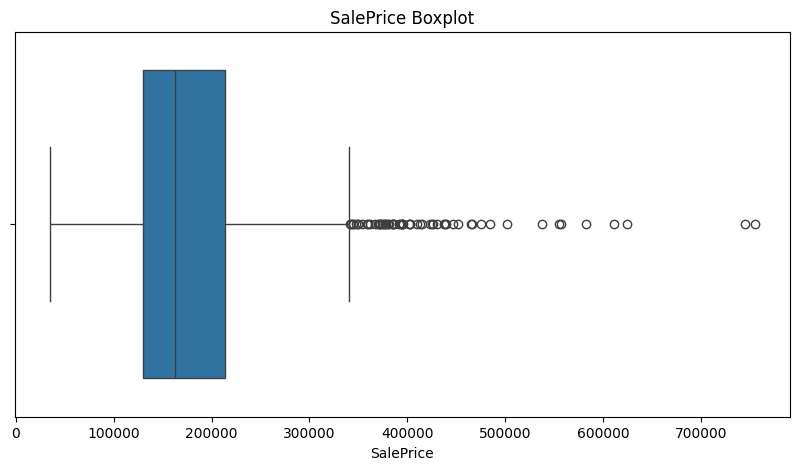

In [76]:
# =========================================================
# SALE PRICE BOXPLOT
# =========================================================

plt.figure(figsize=(10,5))

sns.boxplot(
    x=train_df["SalePrice"]
)

plt.title("SalePrice Boxplot")

plt.show()

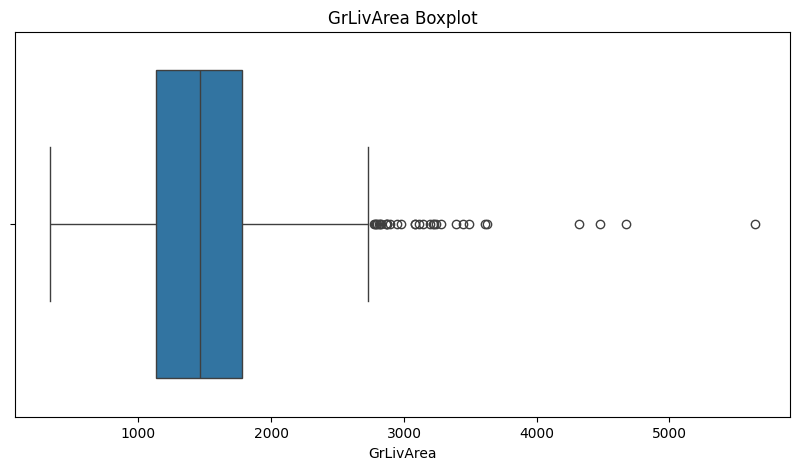

In [77]:
# =========================================================
# GROUND LIVING AREA BOXPLOT
# =========================================================

plt.figure(figsize=(10,5))

sns.boxplot(
    x=train_df["GrLivArea"]
)

plt.title("GrLivArea Boxplot")

plt.show()

# 📌 Observation

From boxplots and scatter plots:
- Some houses contain extremely large living areas
- Some houses have unusually high prices
- These values may act as outliers

Outlier handling can improve:
```python
RMSE Score
```

However, careful removal is important because:
- Real-world expensive houses are valid data
- Removing too many points may reduce model generalization

# 📉 Pairplot Analysis

Pairplots help visualize:
- Relationships between important variables
- Distribution patterns
- Correlation trends

We select top important features for visualization.

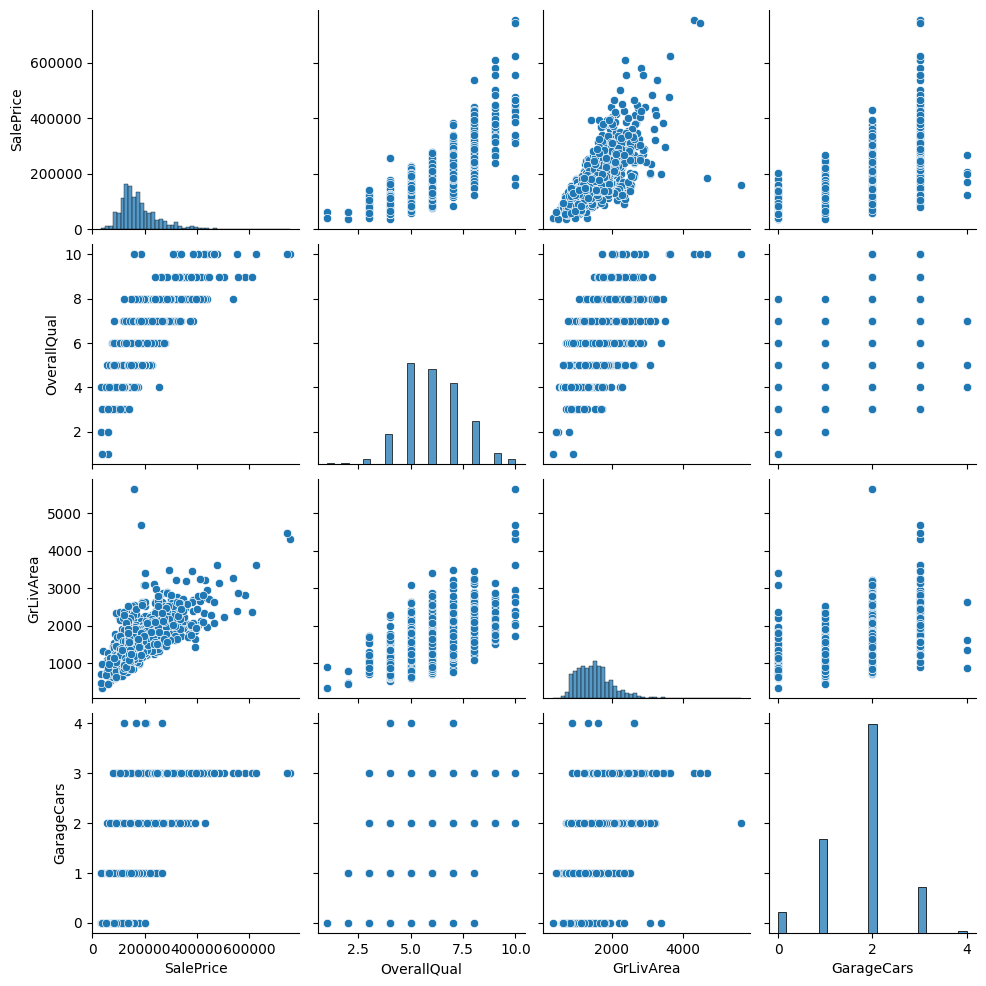

In [78]:
# =========================================================
# PAIRPLOT
# =========================================================

important_features = [
    "SalePrice",
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    # "TotalSF"
]

sns.pairplot(
    train_df[important_features]
)

plt.show()

# ✅ Correlation Analysis Completed

We successfully analyzed:
- Feature relationships
- Important predictors
- Correlation patterns
- Outliers
- Data distributions

The dataset is now ready for:
1. Feature Encoding
2. Train-Test Split
3. Machine Learning Model Training
4. XGBoost Regression
5. Kaggle Submission

# ⚙️ Feature Engineering

Feature engineering is one of the most important steps in machine learning.

The objective is to create new meaningful features from existing data.

Good feature engineering helps:
- Improve prediction accuracy
- Capture hidden relationships
- Improve RMSE score
- Increase model performance

In Kaggle competitions,
feature engineering often provides better improvement than changing algorithms.

# 🏠 House Age Feature

Older houses may have lower prices compared to newer houses.

We create:
```python
HouseAge
```

Formula:
```
Current Year - YearBuilt
```

This feature helps the model understand:
- Property age
- Construction recency
- Building depreciation

In [79]:
# =========================================================
# HOUSE AGE
# =========================================================

train_df["HouseAge"] = (
    2026 - train_df["YearBuilt"]
)

test_df["HouseAge"] = (
    2026 - test_df["YearBuilt"]
)

# 🛠 Remodel Age Feature

Houses renovated recently may have higher market value.

We create:
```python
RemodelAge
```

Formula:
```
Current Year - YearRemodAdd
```

In [80]:
# =========================================================
# REMODEL AGE
# =========================================================

train_df["RemodelAge"] = (
    2026 - train_df["YearRemodAdd"]
)

test_df["RemodelAge"] = (
    2026 - test_df["YearRemodAdd"]
)

# 📐 Total Square Footage

Total house size strongly affects:
```python
SalePrice
```

We combine:
- Basement area
- First floor area
- Second floor area

to create:
```python
TotalSF
```

In [81]:
# =========================================================
# TOTAL SQUARE FOOTAGE
# =========================================================

train_df["TotalSF"] = (
    train_df["TotalBsmtSF"] +
    train_df["1stFlrSF"] +
    train_df["2ndFlrSF"]
)

test_df["TotalSF"] = (
    test_df["TotalBsmtSF"] +
    test_df["1stFlrSF"] +
    test_df["2ndFlrSF"]
)

# 🚿 Total Bathrooms

Bathroom count significantly influences house prices.

We create:
```python
TotalBathrooms
```

Half bathrooms contribute:
```python
0.5
```

Formula:
```
FullBath
+ 0.5 × HalfBath
+ BsmtFullBath
+ 0.5 × BsmtHalfBath
```

In [82]:
# =========================================================
# TOTAL BATHROOMS
# =========================================================

train_df["TotalBathrooms"] = (
    train_df["FullBath"] +
    (0.5 * train_df["HalfBath"]) +
    train_df["BsmtFullBath"] +
    (0.5 * train_df["BsmtHalfBath"])
)

test_df["TotalBathrooms"] = (
    test_df["FullBath"] +
    (0.5 * test_df["HalfBath"]) +
    test_df["BsmtFullBath"] +
    (0.5 * test_df["BsmtHalfBath"])
)

# 🚗 Garage Age Feature

Garage condition and construction year influence:
- Property quality
- Home value

We create:
```python
GarageAge
```

Formula:
```
Current Year - GarageYrBlt
```

In [83]:
# =========================================================
# GARAGE AGE
# =========================================================

train_df["GarageAge"] = (
    2026 - train_df["GarageYrBlt"]
)

test_df["GarageAge"] = (
    2026 - test_df["GarageYrBlt"]
)

# 🌳 Total Porch Area

Outdoor living space affects:
- Home aesthetics
- Lifestyle value
- Property desirability

We combine:
- Open porch
- Enclosed porch
- Screen porch
- Three-season porch

to create:
```python
TotalPorchSF
```

In [84]:
# =========================================================
# TOTAL PORCH AREA
# =========================================================

train_df["TotalPorchSF"] = (
    train_df["OpenPorchSF"] +
    train_df["EnclosedPorch"] +
    train_df["3SsnPorch"] +
    train_df["ScreenPorch"]
)

test_df["TotalPorchSF"] = (
    test_df["OpenPorchSF"] +
    test_df["EnclosedPorch"] +
    test_df["3SsnPorch"] +
    test_df["ScreenPorch"]
)

# ⭐ Total Quality Feature

House quality and condition together strongly influence:
```python
SalePrice
```

We combine:
- OverallQual
- OverallCond

to create:
```python
TotalQuality
```

In [85]:
# =========================================================
# TOTAL QUALITY
# =========================================================

train_df["TotalQuality"] = (
    train_df["OverallQual"] +
    train_df["OverallCond"]
)

test_df["TotalQuality"] = (
    test_df["OverallQual"] +
    test_df["OverallCond"]
)

# 🏡 Total Home Area

We create a larger combined feature representing:
- Living area
- Basement area
- Garage area

This captures overall usable property space.

In [86]:
# =========================================================
# TOTAL HOME AREA
# =========================================================

train_df["TotalHomeArea"] = (
    train_df["GrLivArea"] +
    train_df["TotalBsmtSF"] +
    train_df["GarageArea"]
)

test_df["TotalHomeArea"] = (
    test_df["GrLivArea"] +
    test_df["TotalBsmtSF"] +
    test_df["GarageArea"]
)

# 📊 Analyze Engineered Features

We now analyze the relationship between engineered features and:
```python
SalePrice
```

This helps verify:
- Feature usefulness
- Correlation strength
- Predictive importance

In [87]:
# =========================================================
# ENGINEERED FEATURE CORRELATION
# =========================================================

engineered_features = [
    "HouseAge",
    "RemodelAge",
    "TotalSF",
    "TotalBathrooms",
    "GarageAge",
    "TotalPorchSF",
    "TotalQuality",
    "TotalHomeArea",
    "SalePrice"
]

train_df[engineered_features].corr()["SalePrice"].sort_values(
    ascending=False
)

SalePrice         1.000000
TotalHomeArea     0.807518
TotalSF           0.782260
TotalBathrooms    0.631731
TotalQuality      0.594786
TotalPorchSF      0.195739
GarageAge        -0.466754
RemodelAge       -0.507101
HouseAge         -0.522897
Name: SalePrice, dtype: float64

# 🔥 Heatmap of Engineered Features

We visualize the correlation between engineered features using a heatmap.

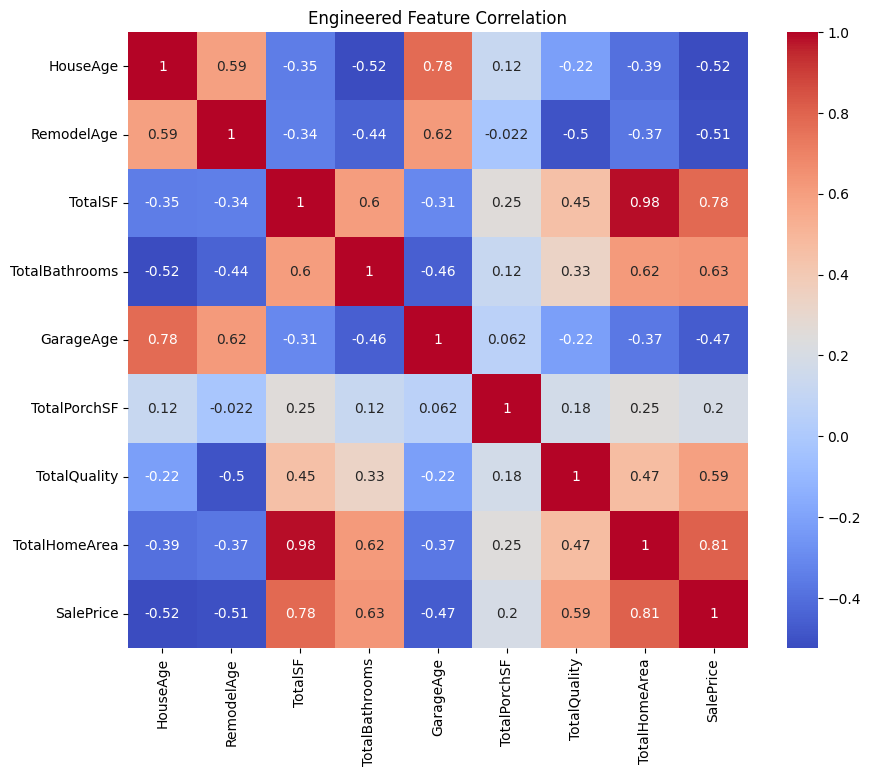

In [88]:
# =========================================================
# ENGINEERED FEATURE HEATMAP
# =========================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    train_df[engineered_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Engineered Feature Correlation")

plt.show()

# ✅ Feature Engineering Completed

We successfully created new features that improve:
- Predictive power
- Feature relationships
- Regression performance

The dataset is now ready for:
1. Encoding categorical variables
2. Train-test split
3. Machine learning model training
4. XGBoost regression
5. Kaggle submission

#  Feature Encoding

Machine learning models cannot directly understand categorical text data.

Examples:
- Neighborhood
- HouseStyle
- Exterior1st

Therefore, categorical features must be converted into numerical form.

We use:
```python
One-Hot Encoding
```

Advantages:
- Preserves category information
- Prevents ordinal assumptions
- Works well for regression models

In [89]:
# =========================================================
# COMBINE TRAIN + TEST DATA
# =========================================================

train_ids = train_df["Id"]

test_ids = test_df["Id"]

y = train_df["SalePrice"]

train_df = train_df.drop(
    ["Id", "SalePrice"],
    axis=1
)

test_df = test_df.drop(
    ["Id"],
    axis=1
)

combined_df = pd.concat(
    [train_df, test_df],
    axis=0
)

#  Apply One-Hot Encoding

Categorical variables are converted into binary numerical columns using:
```python
pd.get_dummies()
```

In [90]:
# =========================================================
# ONE HOT ENCODING
# =========================================================

combined_df = pd.get_dummies(
    combined_df
)

print(
    "Encoded Dataset Shape:",
    combined_df.shape
)

Encoded Dataset Shape: (2919, 310)


#  Separate Train and Test Data

After encoding,
we split the combined dataset back into:
- Training dataset
- Testing dataset

In [91]:
# =========================================================
# SPLIT BACK TRAIN & TEST
# =========================================================

X = combined_df.iloc[
    :len(y),
    :
]

X_test = combined_df.iloc[
    len(y):,
    :
]

print("Train Shape:", X.shape)

print("Test Shape:", X_test.shape)

Train Shape: (1460, 310)
Test Shape: (1459, 310)


#  Train Validation Split

We split the training dataset into:
- Training data
- Validation data

Purpose:
- Evaluate model performance
- Prevent overfitting
- Measure generalization ability

In [92]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)

print("X_val:", X_val.shape)

X_train: (1168, 310)
X_val: (292, 310)


#  Linear Regression Model

Linear Regression is a baseline regression algorithm.

It helps:
- Establish benchmark performance
- Understand linear relationships
- Compare advanced models later

In [93]:
# =========================================================
# LINEAR REGRESSION
# =========================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

lr_preds = lr_model.predict(
    X_val
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        lr_preds
    )
)

print(
    "Linear Regression RMSE:",
    lr_rmse
)

Linear Regression RMSE: 65389.71765374214


#  Random Forest Regressor

Random Forest is an ensemble learning algorithm.

Advantages:
- Handles non-linearity
- Reduces overfitting
- Captures feature interactions

In [94]:
# =========================================================
# RANDOM FOREST REGRESSOR
# =========================================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_preds = rf_model.predict(
    X_val
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        rf_preds
    )
)

print(
    "Random Forest RMSE:",
    rf_rmse
)

Random Forest RMSE: 30357.53268480912


#  XGBoost Regressor

XGBoost is one of the most powerful algorithms for structured/tabular data.

Advantages:
- High accuracy
- Gradient boosting optimization
- Excellent Kaggle performance
- Handles complex feature relationships

In [ ]:
# =========================================================
# INSTALL XGBOOST
# =========================================================

# Uncomment if not installed
# !pip install xgboost

In [95]:
# =========================================================
# XGBOOST REGRESSOR
# =========================================================

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_preds = xgb_model.predict(
    X_val
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        xgb_preds
    )
)

print(
    "XGBoost RMSE:",
    xgb_rmse
)

XGBoost RMSE: 26198.145888592957


#  Model Comparison

We compare:
- Linear Regression
- Random Forest
- XGBoost

Lower RMSE indicates:
```python
Better model performance
```

In [96]:
# =========================================================
# MODEL COMPARISON
# =========================================================

models = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ]
})

models.sort_values(
    by="RMSE"
)

,Model,RMSE
2,XGBoost,26198.145889
1,Random Forest,30357.532685
0,Linear Regression,65389.717654


#  Train Final Model

We now train the best-performing model using:
- Complete training dataset
- All engineered features

In [97]:
# =========================================================
# TRAIN FINAL MODEL
# =========================================================

final_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

final_model.fit(
    X,
    y
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

#  Generate Predictions

The trained model predicts house prices for:
```python
test.csv
```

In [98]:
# =========================================================
# TEST PREDICTIONS
# =========================================================

predictions = final_model.predict(
    X_test
)

predictions[:10]

array([128100.57, 162105.62, 181832.88, 187627.19, 181025.84, 173661.89,
       176965.95, 169750.58, 192839.8 , 125663.3 ], dtype=float32)

#  Create Submission File

Kaggle requires predictions in the following format:

```text
Id,SalePrice
```

We now generate the final submission CSV file.

In [100]:
submission = pd.DataFrame({

    "Id": test_ids,

    "SalePrice": predictions
})
submission.head()

,Id,SalePrice
0,1461,128100.570312
1,1462,162105.625000
2,1463,181832.875000
3,1464,187627.187500
4,1465,181025.843750


In [101]:
# =========================================================
# SAVE SUBMISSION
# =========================================================

submission.to_csv(
    "submission.csv",
    index=False
)

print(
    "submission.csv file created successfully!"
)

submission.csv file created successfully!


# Upload to Kaggle

Final Steps:
1. Open Kaggle competition page
2. Click:
```text
Submit Prediction
```
3. Upload:
```text
submission.csv
```
4. View leaderboard score

The competition evaluates submissions using:
```python
RMSE
```
on logarithmic house prices.